In [1]:
import os

# Core LSD imports
from sclsd.core import LSDConfig
from sclsd.train import LSD
from sclsd.utils import set_all_seeds


# Scientific computing
import pandas as pd
import numpy as np

# Deep learning
import torch


# Single-cell analysis
import scanpy as sc



/scratch/apour/conda/envs/sclsd/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Set random seeds for reproducibility
SEED = 42
set_all_seeds(SEED)

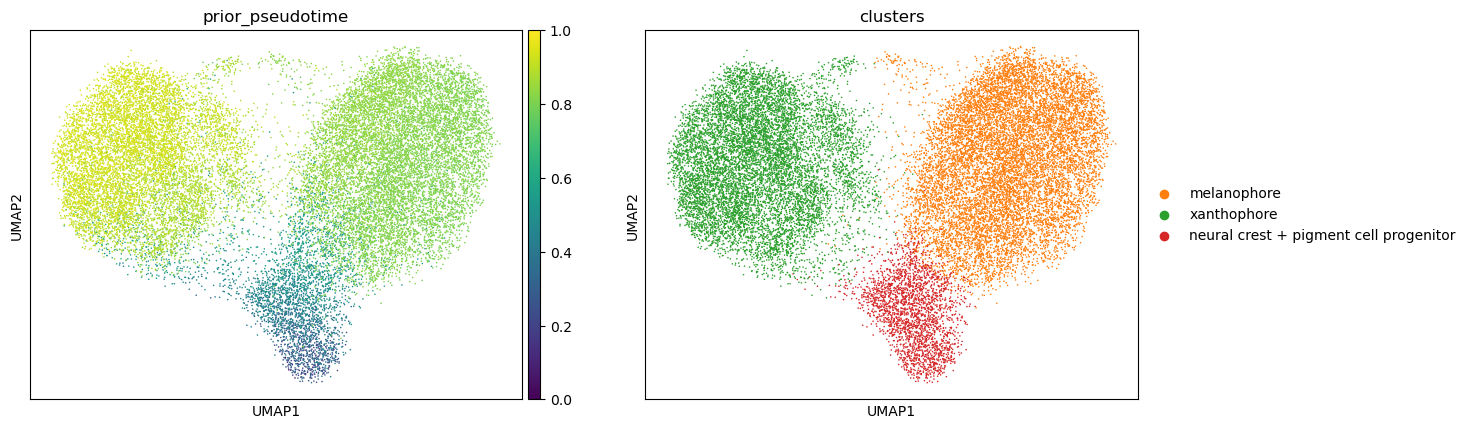

In [ ]:
adata = sc.read("../../Zenodo/Zebrafish_Pigment/preprocessed_adata.h5ad")
mask = ~adata.obs["timepoint"].astype(str).eq("72")
adata = adata[mask].copy()
sc.pl.umap(adata, color = ["prior_pseudotime", "clusters"])

In [4]:
# Configure optimization hyperparameters
cfg = LSDConfig()


# Initialize LSD model
lsd = LSD(
    adata,
    cfg,
    device=device,

)

In [5]:
model_dir = "./model"
lsd.load(model_dir,"lsd_model_epoch0060.pth")
#extract LSD outputs (transition matrix, potantial, entropy, pseudotime)
final_adata = lsd.get_adata()

#predict cell fates
dyn_adata = lsd.get_cell_fates(final_adata , time_range = 20, cluster_key = "clusters", batch_size = 2048)

[LSD] Model and Pyro parameters loaded from ./model/lsd_model_epoch0060.pth


/scratch/apour/conda/envs/sclsd/lib/python3.10/site-packages/sclsd/train/trainer.py:894: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  predicted_fates = adata.obs[cluster_key][nn.cpu().numpy()].values


plotting LSD outputs on force directed projection


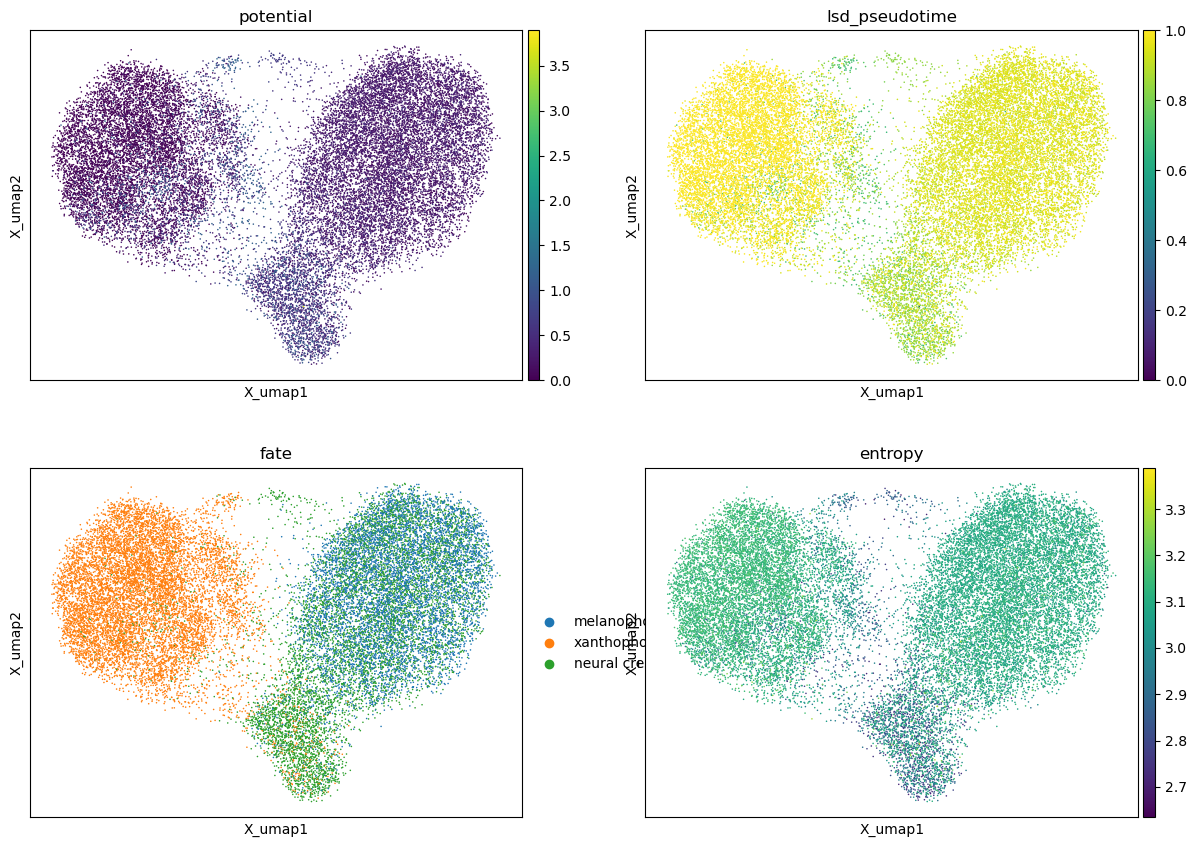

plotting LSD outputs on diffrentiation state projection


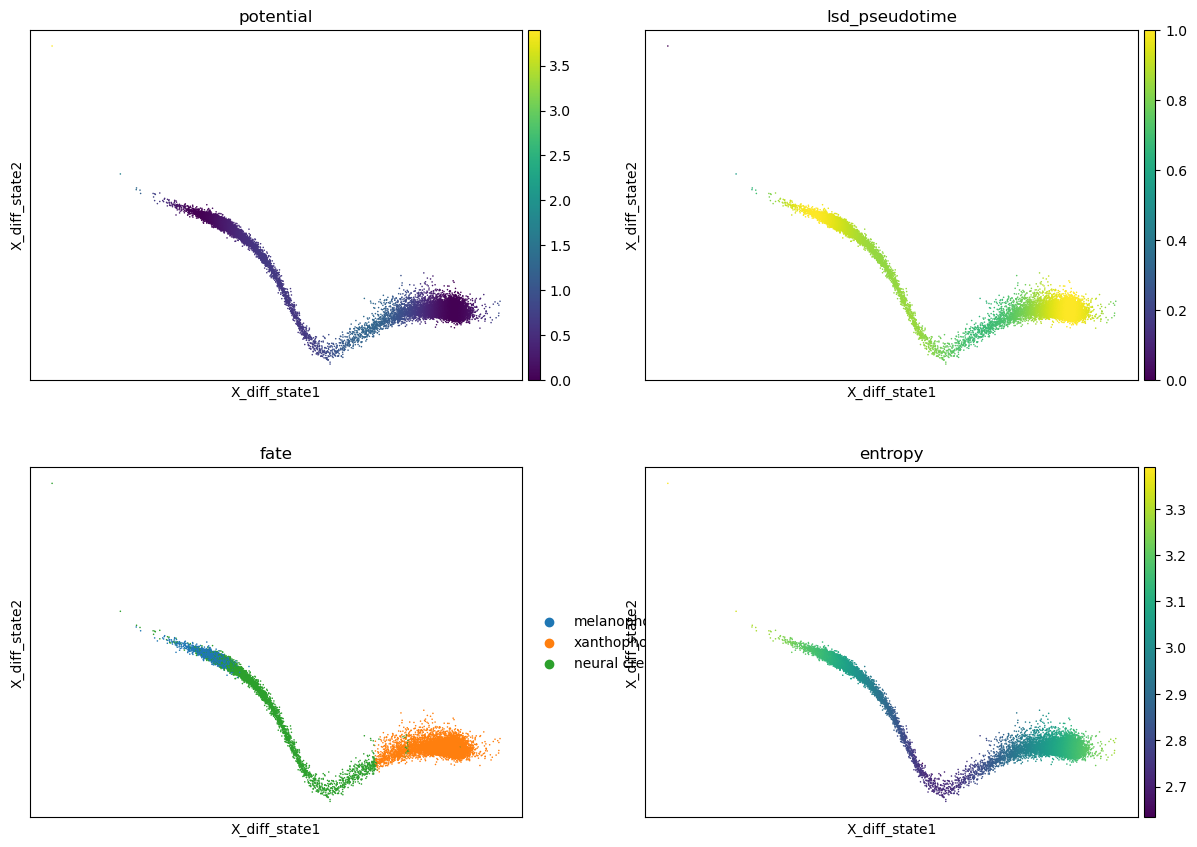

plotting LSD streamlines on force directed projection


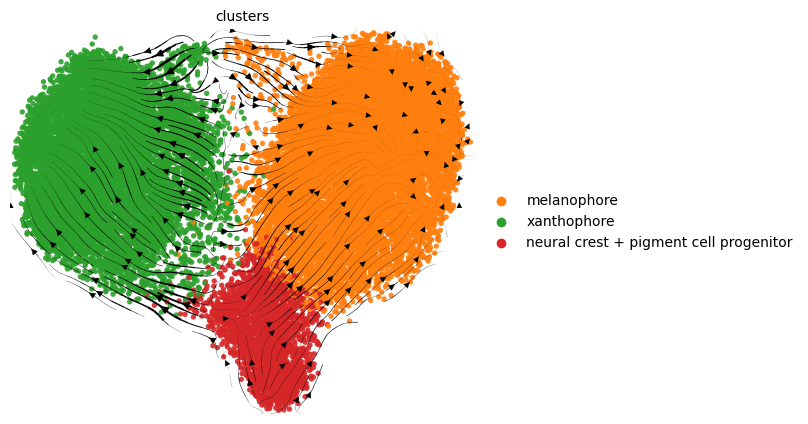

<Axes: title={'center': 'clusters'}>

In [6]:
#plot lsd outputs
cols = ["potential", "lsd_pseudotime", "fate", "entropy"]

print("="* 60)
print("plotting LSD outputs on force directed projection")
print("="* 60)
sc.pl.embedding(dyn_adata, color = cols, basis = "X_umap", ncols = 2)

print("="* 60)
print("plotting LSD outputs on diffrentiation state projection")
print("="* 60)
sc.pl.embedding(dyn_adata, color = cols, basis = "X_diff_state", ncols = 2)

print("="* 60)
print("plotting LSD streamlines on force directed projection")
print("="* 60)
lsd.stream_lines(embedding= "X_umap", size = 60)


In [7]:
KO_COLUMNS = [
    "Gene",
    "Perturbed_Xan_count", "Unperturbed_Xan_count",
    "Perturbed_Mel_count", "Unperturbed_Mel_count",
    "Xan_LogFC", "Mel_LogFC",
    "Total_cells",
]


def validate_ko_results(frame, gene_names, require_complete=False):
    gene_names = [str(gene) for gene in gene_names]
    if len(gene_names) != len(set(gene_names)):
        raise ValueError("Canonical gene names must be unique.")

    missing_columns = set(KO_COLUMNS) - set(frame.columns)
    if missing_columns:
        raise ValueError(
            f"KO results are missing columns: {sorted(missing_columns)}"
        )

    result = frame.loc[:, KO_COLUMNS].copy()
    result["Gene"] = result["Gene"].astype(str)

    duplicate_genes = result.loc[result["Gene"].duplicated(), "Gene"].unique()
    if len(duplicate_genes):
        raise ValueError(
            f"KO results contain duplicate genes: {duplicate_genes.tolist()}"
        )

    expected = set(gene_names)
    observed = set(result["Gene"])
    unexpected = observed - expected
    if unexpected:
        raise ValueError(
            f"KO results contain unexpected genes: {sorted(unexpected)}"
        )

    if require_complete and observed != expected:
        missing = expected - observed
        raise ValueError(
            f"KO results are incomplete; {len(missing)} genes are missing."
        )

    gene_order = {gene: position for position, gene in enumerate(gene_names)}
    result["_gene_order"] = result["Gene"].map(gene_order)
    result = (
        result.sort_values("_gene_order")
        .drop(columns="_gene_order")
        .reset_index(drop=True)
    )
    return result


def atomic_write_csv(frame, path):
    path = os.fspath(path)
    temporary_path = f"{path}.tmp"
    frame.to_csv(temporary_path, index=False)
    os.replace(temporary_path, path)


def load_ko_progress(checkpoint_path, final_path, gene_names):
    if os.path.exists(final_path):
        final = pd.read_csv(final_path, dtype={"Gene": str})
        return validate_ko_results(
            final, gene_names, require_complete=True
        ), True

    if os.path.exists(checkpoint_path):
        checkpoint = pd.read_csv(checkpoint_path, dtype={"Gene": str})
        return validate_ko_results(
            checkpoint, gene_names, require_complete=False
        ), False

    return pd.DataFrame(columns=KO_COLUMNS), False


def build_ko_result(
    gene, perturbed_fates, unperturbed_fates, total_cells, pseudocount=1e-3
):
    fate_labels = {
        "Xan": "xanthophore",
        "Mel": "melanophore",
    }

    result = {"Gene": str(gene)}
    for abbreviation, fate in fate_labels.items():
        perturbed_count = int(np.sum(perturbed_fates == fate))
        unperturbed_count = int(np.sum(unperturbed_fates == fate))
        result[f"Perturbed_{abbreviation}_count"] = perturbed_count
        result[f"Unperturbed_{abbreviation}_count"] = unperturbed_count
        result[f"{abbreviation}_LogFC"] = np.log2(
            (perturbed_count + pseudocount)
            / (unperturbed_count + pseudocount)
        )

    result["Total_cells"] = int(total_cells)
    return result


def run_gene_ko_screen(
    gene_names, evaluate_gene, checkpoint_path, final_path
):
    gene_names = [str(gene) for gene in gene_names]
    progress, is_complete = load_ko_progress(
        checkpoint_path, final_path, gene_names
    )

    if is_complete:
        print(f"Loaded complete gene-KO results from {final_path}")
        return progress

    completed_genes = set(progress["Gene"])
    remaining_genes = [
        gene for gene in gene_names if gene not in completed_genes
    ]
    rows = progress.to_dict(orient="records")

    print(
        f"Loaded {len(completed_genes)} completed genes; "
        f"{len(remaining_genes)} remain."
    )
    for gene in tqdm(
        remaining_genes, desc="Perturbing genes", total=len(remaining_genes)
    ):
        rows.append(evaluate_gene(gene))
        checkpoint = validate_ko_results(
            pd.DataFrame(rows, columns=KO_COLUMNS),
            gene_names,
            require_complete=False,
        )
        atomic_write_csv(checkpoint, checkpoint_path)

    result = validate_ko_results(
        pd.DataFrame(rows, columns=KO_COLUMNS),
        gene_names,
        require_complete=True,
    )
    atomic_write_csv(result, final_path)
    print(f"Checkpoint saved to {checkpoint_path}")
    print(f"Complete gene-KO results saved to {final_path}")
    return result

In [8]:
# Large-scale gene KO with restart-safe checkpointing
from tqdm.auto import tqdm
gene_names = [
      "ENSDARG00000059279",  # tfap2a
      "ENSDARG00000021032",  # foxd3
      "ENSDARG00000036292",  # cdx4
      "ENSDARG00000042826",  # egr2b
      "ENSDARG00000104566",  # foxi1
      "ENSDARG00000008305",  # hand2
      "ENSDARG00000008174",  # hoxb1a
      "ENSDARG00000017121",  # mafba
      "ENSDARG00000021201",  # noto
      "ENSDARG00000007406",  # phox2a
      "ENSDARG00000031891",  # tbx1
      "ENSDARG00000007329",  # tbx16
      "ENSDARG00000101576",  # tbxta
]
# gene_names = dyn_adata.var_names.astype(str).tolist()
ko_dir = os.path.join(model_dir, "gene_ko")
os.makedirs(ko_dir, exist_ok=True)
checkpoint_path = os.path.join(ko_dir, "gene_ko_checkpoint.csv")
final_path = os.path.join(ko_dir, "gene_ko_results.csv")

x = torch.from_numpy(dyn_adata.X.toarray()).float()
idx = np.where(
    dyn_adata.obs["clusters"] == "neural crest + pigment cell progenitor"
)[0]
IC = x[idx].to(device)


def evaluate_gene_knockout(gene):
    perturbed_fates, unperturbed_fates = lsd.perturb(
        adata=dyn_adata,
        x=IC,
        gene_name=gene,
        dt_pert= 0.2,
        cluster_key="clusters",
        batch_size=4096,
    )
    return build_ko_result(
        gene,
        perturbed_fates,
        unperturbed_fates,
        total_cells=len(IC),
    )


df = run_gene_ko_screen(
    gene_names,
    evaluate_gene_knockout,
    checkpoint_path,
    final_path,
)
df

Loaded 0 completed genes; 13 remain.


Perturbing genes:   0%|          | 0/13 [00:00<?, ?it/s]

Perturbing genes: 100%|██████████| 13/13 [01:17<00:00,  5.94s/it]

Checkpoint saved to ./model/gene_ko/gene_ko_checkpoint.csv
Complete gene-KO results saved to ./model/gene_ko/gene_ko_results.csv


,Gene,Perturbed_Xan_count,Unperturbed_Xan_count,Perturbed_Mel_count,Unperturbed_Mel_count,Xan_LogFC,Mel_LogFC,Total_cells
0,ENSDARG00000059279,295,296,424,917,-0.004882,-1.112856,2502
1,ENSDARG00000021032,294,296,1052,917,-0.009781,0.198141,2502
2,ENSDARG00000036292,296,296,915,917,0.000000,-0.003150,2502
3,ENSDARG00000042826,296,296,916,917,0.000000,-0.001574,2502
4,ENSDARG00000104566,296,296,917,917,0.000000,0.000000,2502
5,ENSDARG00000008305,296,296,917,917,0.000000,0.000000,2502
6,ENSDARG00000008174,296,296,917,917,0.000000,0.000000,2502
7,ENSDARG00000017121,296,296,918,917,0.000000,0.001572,2502
8,ENSDARG00000021201,296,296,916,917,0.000000,-0.001574,2502
9,ENSDARG00000007406,296,296,917,917,0.000000,0.000000,2502
